# EMS741 - Coursework - few-shot learning for medical image segmentation

Team 8: Timothy Lundberg, Oluwaniyi Momoh, Kabisan Thayaparan

The data for the coursework is available [here](https://zenodo.org/records/18745413), and can be downloaded as follows.

In [1]:
!wget -q -O data.zip https://zenodo.org/records/18745413/files/ems741_cw_data.zip?download=1
print('Download complete.')

Download complete.


'wget' is not recognized as an internal or external command,
operable program or batch file.


In [ ]:
import zipfile
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'
print("✅ OpenMP conflict fixed")

!nvidia-smi -L || echo 'No GPU visible (CPU only)'

path_to_zip = r'data.zip'
path_to_extract_to = r'./'

if not os.path.exists('./train'):
    with zipfile.ZipFile(path_to_zip, 'r') as zip_ref:
        zip_ref.extractall(path_to_extract_to)
print('Extraction complete.')

Extraction complete.


In [3]:
print('Train tasks:')
!ls ./train
print('\nVal tasks:')
!ls ./val
print('\nTest tasks:')
!ls ./test

Train tasks:
task_2	task_3	task_5	task_7

Val tasks:
task_4	task_6

Test tasks:
task_1	task_8


### Your approach

Below is the complete pipeline: data loading, model definition, training, few-shot adaptation, and visualization.

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import glob
import os
from sklearn.model_selection import train_test_split

# Set device
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

# For Dice metric
def dice_coefficient(pred, target, smooth=1e-6):
    pred = torch.sigmoid(pred)
    pred = (pred > 0.5).float()
    intersection = (pred * target).sum()
    return (2. * intersection + smooth) / (pred.sum() + target.sum() + smooth)

Using device: cuda


In [5]:
class MedicalSegmentationDataset(Dataset):
    def __init__(self, task_folder):
        self.images = sorted(glob.glob(f"{task_folder}/images/*.png"))
        self.masks = sorted(glob.glob(f"{task_folder}/masks/*.png"))
        assert len(self.images) == len(self.masks), "Mismatch between images and masks"
    
    def __len__(self):
        return len(self.images)
    
    def __getitem__(self, idx):
        img = np.array(Image.open(self.images[idx]).convert('L')) / 255.0
        mask = np.array(Image.open(self.masks[idx]).convert('L')) / 255.0
        img = torch.from_numpy(img).float().unsqueeze(0)  # [1, H, W]
        mask = torch.from_numpy(mask).float().unsqueeze(0)  # [1, H, W]
        return img, mask

# Quick test
if os.path.exists('./train/task_2'):
    dataset = MedicalSegmentationDataset('./train/task_2')
    print(f"Task 2 has {len(dataset)} slices")
    img, mask = dataset[0]
    print(f"Image shape: {img.shape}, Mask shape: {mask.shape}")

Task 2 has 1011 slices
Image shape: torch.Size([1, 192, 192]), Mask shape: torch.Size([1, 192, 192])


In [6]:
class SimpleUNet(nn.Module):
    def __init__(self):
        super().__init__()
        # Encoder
        self.enc1 = nn.Sequential(nn.Conv2d(1, 32, 3, padding=1), nn.ReLU(), nn.Conv2d(32, 32, 3, padding=1), nn.ReLU())
        self.pool1 = nn.MaxPool2d(2)
        self.enc2 = nn.Sequential(nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.Conv2d(64, 64, 3, padding=1), nn.ReLU())
        
        # Bottleneck
        self.bottleneck = nn.Sequential(nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.Conv2d(128, 128, 3, padding=1), nn.ReLU())
        
        # Decoder
        self.upconv2 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec2 = nn.Sequential(nn.Conv2d(128, 64, 3, padding=1), nn.ReLU(), nn.Conv2d(64, 64, 3, padding=1), nn.ReLU())
        self.upconv1 = nn.ConvTranspose2d(64, 32, 2, stride=2)
        self.dec1 = nn.Sequential(nn.Conv2d(64, 32, 3, padding=1), nn.ReLU(), nn.Conv2d(32, 32, 3, padding=1), nn.ReLU())
        self.final = nn.Conv2d(32, 1, 1)
    
    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool1(e1))
        b = self.bottleneck(self.pool1(e2))
        
        d2 = self.upconv2(b)
        if d2.shape != e2.shape:
            d2 = torch.nn.functional.interpolate(d2, size=e2.shape[2:])
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)
        
        d1 = self.upconv1(d2)
        if d1.shape != e1.shape:
            d1 = torch.nn.functional.interpolate(d1, size=e1.shape[2:])
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)
        
        return self.final(d1)

# Test model
model = SimpleUNet()
test_input = torch.randn(1, 1, 256, 256)
print(f"Model output shape: {model(test_input).shape}")

Model output shape: torch.Size([1, 1, 256, 256])


In [7]:
def train_baseline(model, train_loader, val_loader, epochs=10, lr=1e-3):
    model.to(device)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    train_losses, val_dices = [], []
    
    for epoch in range(epochs):
        model.train()
        train_loss = 0
        for imgs, masks in train_loader:
            imgs, masks = imgs.to(device), masks.to(device)
            optimizer.zero_grad()
            preds = model(imgs)
            loss = criterion(preds, masks)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        
        model.eval()
        val_dice = 0
        with torch.no_grad():
            for imgs, masks in val_loader:
                imgs, masks = imgs.to(device), masks.to(device)
                preds = model(imgs)
                val_dice += dice_coefficient(preds, masks).item()
        
        avg_train_loss = train_loss/len(train_loader)
        avg_val_dice = val_dice/len(val_loader)
        train_losses.append(avg_train_loss)
        val_dices.append(avg_val_dice)
        print(f"Epoch {epoch+1}/{epochs}: Train loss {avg_train_loss:.4f}, Val Dice {avg_val_dice:.4f}")
    
    return train_losses, val_dices

In [8]:
def few_shot_adapt(model, support_imgs, support_masks, query_loader, n_steps=20, lr=1e-3):
    import copy
    adapted_model = copy.deepcopy(model)
    adapted_model.to(device)
    adapted_model.train()
    
    optimizer = optim.Adam(adapted_model.parameters(), lr=lr)
    criterion = nn.BCEWithLogitsLoss()
    
    support_imgs, support_masks = support_imgs.to(device), support_masks.to(device)
    for step in range(n_steps):
        optimizer.zero_grad()
        preds = adapted_model(support_imgs)
        loss = criterion(preds, support_masks)
        loss.backward()
        optimizer.step()
    
    adapted_model.eval()
    total_dice = 0
    with torch.no_grad():
        for q_imgs, q_masks in query_loader:
            q_imgs, q_masks = q_imgs.to(device), q_masks.to(device)
            preds = adapted_model(q_imgs)
            total_dice += dice_coefficient(preds, q_masks).item()
            
    return adapted_model, total_dice / len(query_loader)

Training Baseline on Task 2...
Epoch 1/5: Train loss 0.1404, Val Dice 0.0000
Epoch 2/5: Train loss 0.0888, Val Dice 0.0331
Epoch 3/5: Train loss 0.0816, Val Dice 0.1166
Epoch 4/5: Train loss 0.0686, Val Dice 0.5967
Epoch 5/5: Train loss 0.0590, Val Dice 0.5852


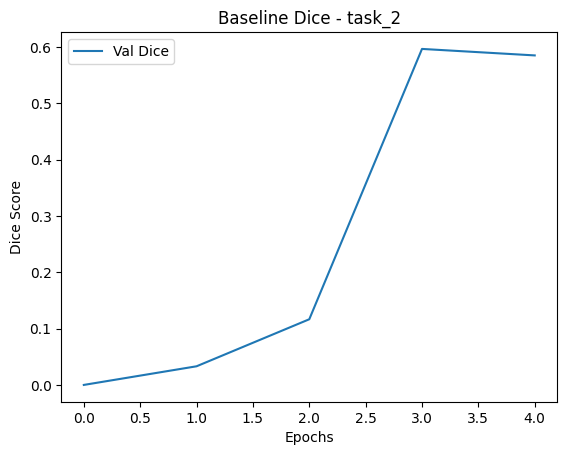

In [9]:
# Execute Baseline
if os.path.exists('./train/task_2'):
    print("Training Baseline on Task 2...")
    task_name = 'task_2'
    dataset = MedicalSegmentationDataset(f'./train/{task_name}')
    
    train_idx, val_idx = train_test_split(range(len(dataset)), test_size=0.2, random_state=42)
    train_ds = torch.utils.data.Subset(dataset, train_idx)
    val_ds = torch.utils.data.Subset(dataset, val_idx)

    train_loader = DataLoader(train_ds, batch_size=4, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=4)

    model_baseline = SimpleUNet()
    # Set epochs=10 or 20 for real runs
    train_losses, val_dices = train_baseline(model_baseline, train_loader, val_loader, epochs=5)

    plt.plot(val_dices, label='Val Dice')
    plt.title(f'Baseline Dice - {task_name}')
    plt.xlabel('Epochs')
    plt.ylabel('Dice Score')
    plt.legend()
    plt.show()

In [10]:
# Execute Few-Shot Experiments
if os.path.exists('./val/task_4'):
    print("Running Few-Shot adaptation on Task 4...")
    new_task = './val/task_4'
    dataset_new = MedicalSegmentationDataset(new_task)

    results = {}
    models_dict = {}
    
    for n_shot in [1, 3, 5]:
        all_indices = np.arange(len(dataset_new))
        support_idx = np.random.choice(all_indices, n_shot, replace=False)
        query_idx = np.setdiff1d(all_indices, support_idx)
        
        support_ds = torch.utils.data.Subset(dataset_new, support_idx)
        query_ds = torch.utils.data.Subset(dataset_new, query_idx[:20]) # Limit query set for speed testing
        
        support_loader = DataLoader(support_ds, batch_size=n_shot, shuffle=False)
        query_loader = DataLoader(query_ds, batch_size=2, shuffle=False)
        
        support_imgs, support_masks = next(iter(support_loader))
        
        adapted_model, query_dice = few_shot_adapt(model_baseline, support_imgs, support_masks, query_loader, n_steps=20)
        
        results[n_shot] = query_dice
        models_dict[n_shot] = adapted_model
        print(f"{n_shot}-shot Dice on Query Set: {query_dice:.4f}")

    print("\nSummary of Few-Shot Results:", results)

Running Few-Shot adaptation on Task 4...
1-shot Dice on Query Set: 0.1000
3-shot Dice on Query Set: 0.1000
5-shot Dice on Query Set: 0.1000

Summary of Few-Shot Results: {1: 0.1000000008317522, 3: 0.1000000008317522, 5: 0.1000000008317522}


Visualizing 5-shot predictions...


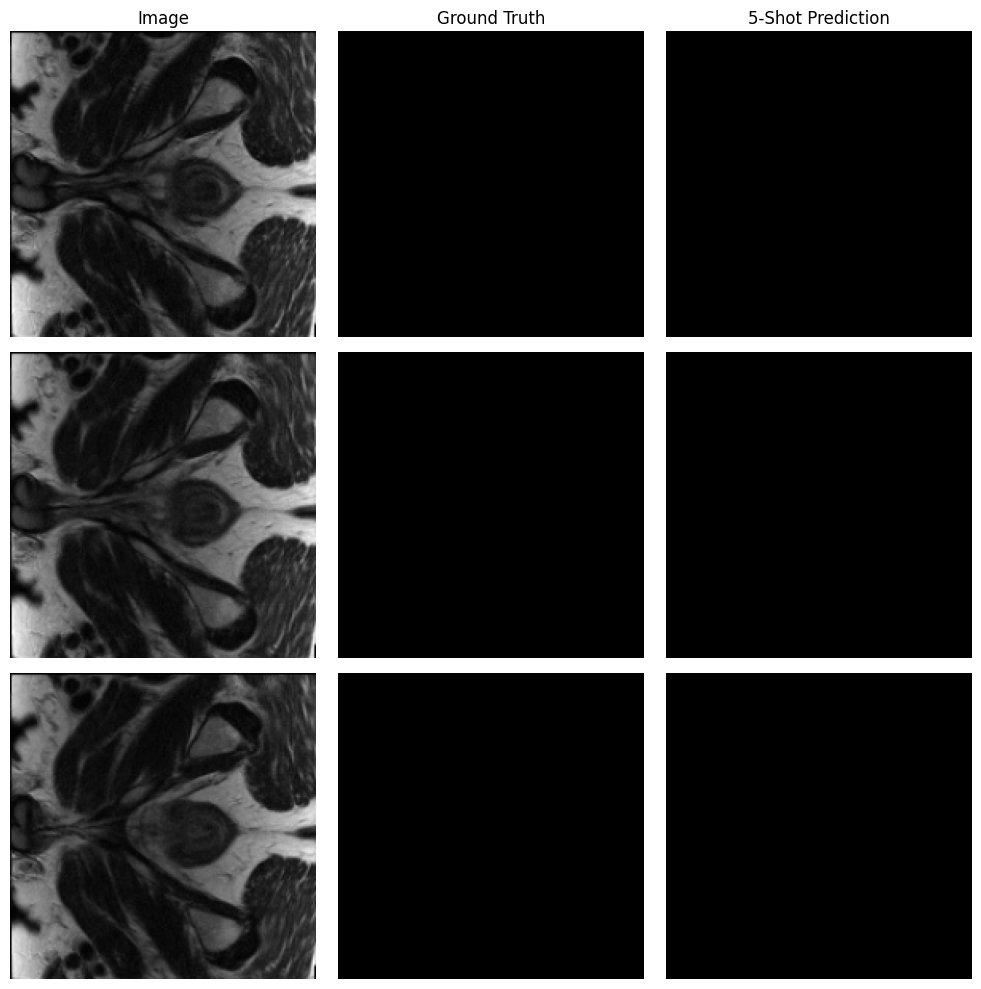

In [11]:
# Visualization
if os.path.exists('./val/task_4'):
    print("Visualizing 5-shot predictions...")
    best_model = models_dict[5]
    best_model.eval()
    
    query_ds = torch.utils.data.Subset(dataset_new, query_idx[:3])
    viz_loader = DataLoader(query_ds, batch_size=1)
    
    fig, axes = plt.subplots(3, 3, figsize=(10, 10))
    
    with torch.no_grad():
        for i, (img, mask) in enumerate(viz_loader):
            if i >= 3: break
            pred = best_model(img.to(device))
            pred = torch.sigmoid(pred).cpu()
            pred_binary = (pred > 0.5).float()
            
            axes[i, 0].imshow(img[0, 0].numpy(), cmap='gray')
            if i == 0: axes[i, 0].set_title('Image')
            axes[i, 0].axis('off')
            
            axes[i, 1].imshow(mask[0, 0].numpy(), cmap='gray')
            if i == 0: axes[i, 1].set_title('Ground Truth')
            axes[i, 1].axis('off')
            
            axes[i, 2].imshow(pred_binary[0, 0].numpy(), cmap='gray')
            if i == 0: axes[i, 2].set_title('5-Shot Prediction')
            axes[i, 2].axis('off')
            
    plt.tight_layout()
    plt.show()